In [ ]:
#PART A OBJECT DETECTION AND IMAGE CAPTIONING
import os
import urllib.request
import torch
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torchvision.transforms as T
!pip install transformers

from transformers import VisionEncoderDecoderModel, ViTFeatureExtractor, AutoTokenizer
import torch
from PIL import Image


# 5 image IDs
image_ids = [
    "000a1f347a775121",
    "0000ff7af1656fab",
    "000b55e339f0b131",
    "000c6c92c80213ff",
    "000bbe8285cd3707"
]

# directory for images
os.makedirs("images", exist_ok=True)

# Open Images
base_url = "https://open-images-dataset.s3.amazonaws.com/train/"

# Download
image_paths = []
for img_id in image_ids:
    img_url = f"{base_url}{img_id}.jpg"
    save_path = f"images/{img_id}.jpg"
    try:
        urllib.request.urlretrieve(img_url, save_path)
        print(f"✅ Downloaded: {img_id}.jpg")
        image_paths.append(save_path)
    except Exception as e:
        print(f"❌ Failed to download {img_id}: {e}")


✅ Downloaded: 000a1f347a775121.jpg
✅ Downloaded: 0000ff7af1656fab.jpg
✅ Downloaded: 000b55e339f0b131.jpg
✅ Downloaded: 000c6c92c80213ff.jpg
✅ Downloaded: 000bbe8285cd3707.jpg


Image: 000a1f347a775121.jpg | Detected 4 objects.


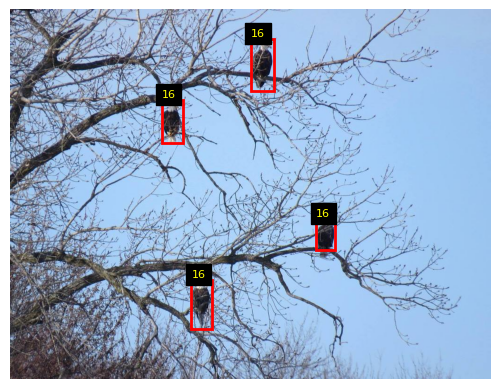

Image: 0000ff7af1656fab.jpg | Detected 2 objects.


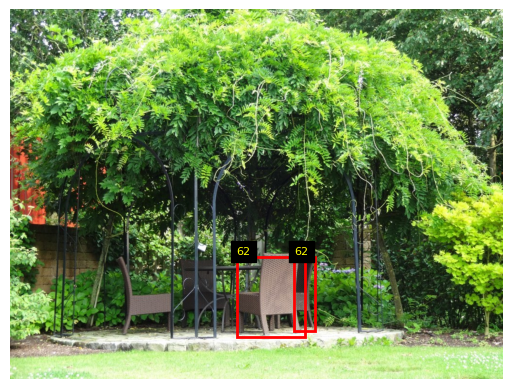

Image: 000b55e339f0b131.jpg | Detected 4 objects.


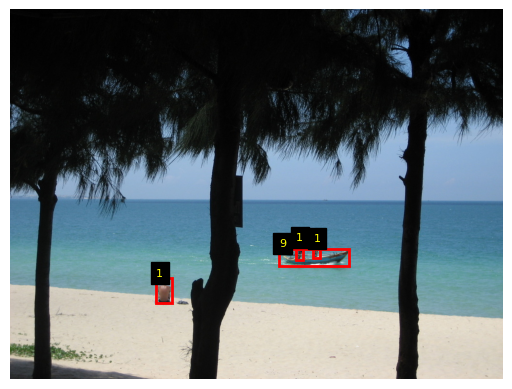

Image: 000c6c92c80213ff.jpg | Detected 26 objects.


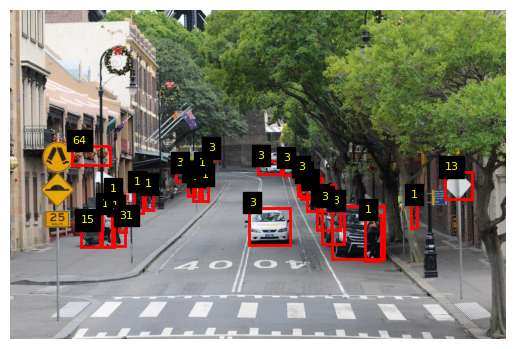

Image: 000bbe8285cd3707.jpg | Detected 2 objects.


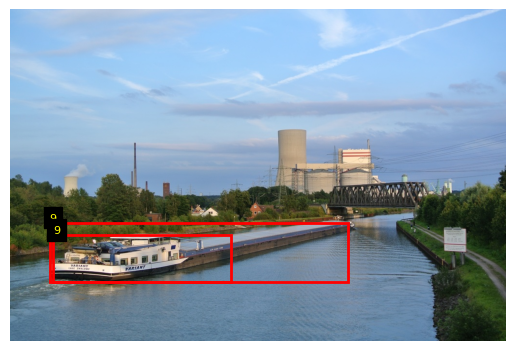

In [ ]:

#5 image IDs
image_ids = [
    "000a1f347a775121",
    "0000ff7af1656fab",
    "000b55e339f0b131",
    "000c6c92c80213ff",
    "000bbe8285cd3707"
]

# Model selection: 'fasterrcnn' and 'maskrcnn'
model_type = 'fasterrcnn'

# Model loading functions
def get_faster_rcnn_model(num_classes=91):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    model.eval()
    return model

def get_mask_rcnn_model(num_classes=91):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
    model.eval()
    return model

# Visualization function
def plot_image_with_boxes(image, boxes, labels=None):
    fig, ax = plt.subplots(1)
    ax.imshow(image)
    if labels is not None:
        labels = labels.cpu() if torch.is_tensor(labels) else labels
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        if labels is not None:
            ax.text(x1, y1 - 5, str(labels[i].item()), color='yellow',
                    fontsize=8, backgroundcolor='black')
    plt.axis('off')
    plt.show()

# Main inference loop
if __name__ == '__main__':
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    #model
    if model_type == 'fasterrcnn':
        model = get_faster_rcnn_model()
    elif model_type == 'maskrcnn':
        model = get_mask_rcnn_model()
    else:
        raise ValueError("Use 'fasterrcnn' and 'maskrcnn' for inference on arbitrary images.")

    model.to(device)
    transform = T.Compose([T.ToTensor()])

    for img_id in image_ids:
        img_path = f'images/{img_id}.jpg'
        image_pil = Image.open(img_path).convert("RGB")
        image_tensor = transform(image_pil).to(device)
        with torch.no_grad():
            prediction = model([image_tensor])[0]
        # Filter boxes with a confidence threshold
        keep = prediction['scores'] > 0.6
        boxes = prediction['boxes'][keep].cpu()
        labels = prediction['labels'][keep].cpu()
        print(f"Image: {img_id}.jpg | Detected {len(boxes)} objects.")
        plot_image_with_boxes(image_pil, boxes, labels)


In [ ]:

#pre-trained model and tokenizer
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
feature_extractor = ViTFeatureExtractor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

max_length = 16
num_beams = 4

def predict_step(image_paths):
  images = []
  for image_path in image_paths:
    i_image = Image.open(image_path)
    if i_image.mode != "RGB":
      i_image = i_image.convert(mode="RGB")
    images.append(i_image)

  pixel_values = feature_extractor(images=images, return_tensors="pt").pixel_values
  pixel_values = pixel_values.to(device)

  output_ids = model.generate(pixel_values, max_length=max_length, num_beams=num_beams)

  preds = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
  preds = [pred.strip() for pred in preds]
  return preds


image_paths = [f"images/{img_id}.jpg" for img_id in image_ids]
captions = predict_step(image_paths)


for i, caption in enumerate(captions):
  print(f"Image: {image_ids[i]}.jpg | Caption: {caption}")


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.51.3"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_to

Image: 000a1f347a775121.jpg | Caption: a bird perched on top of a tree branch
Image: 0000ff7af1656fab.jpg | Caption: a wooden bench sitting in the middle of a garden
Image: 000b55e339f0b131.jpg | Caption: a beach scene with a boat and people on the beach
Image: 000c6c92c80213ff.jpg | Caption: a city street filled with lots of traffic
Image: 000bbe8285cd3707.jpg | Caption: a boat traveling down a river next to a large body of water
